# Austin Crime Clearance: What Takes Longer?

We look at how reported Austin crime cases were cleared, which case types take the longest to clear, and whether clearance timing differs between arrests and exceptions. We use clearance time only for cases marked C or O. The date recorded for not-cleared cases is ambiguous, so we do not treat it as a delay measure.

We work with `austin_crime.csv`, which contains individual reported crimes from Austin.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from scipy import stats
from IPython.display import display

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')

In [2]:
new_file = Path('austin_crime.csv')
provided_file = Path('crime-housing-austin-2015.csv')

if new_file.exists():
    raw = pd.read_csv(new_file)
    source_name = new_file.name
    date_format = None
    column_map = {
        'unique_key': 'case_id',
        'primary_type': 'crime_type',
        'district': 'district',
        'zipcode': 'zip_code',
        'timestamp': 'report_date',
        'clearance_date': 'clearance_date',
        'clearance_status': 'clearance_status'
    }
elif provided_file.exists():
    raw = pd.read_csv(provided_file)
    source_name = provided_file.name
    date_format = '%d-%b-%y'
    column_map = {
        'Key': 'case_id',
        'Highest_NIBRS_UCR_Offense_Description': 'crime_type',
        'District': 'district',
        'Zip_Code_Crime': 'zip_code',
        'Report_Date': 'report_date',
        'Clearance_Date': 'clearance_date',
        'Clearance_Status': 'clearance_status'
    }
else:
    raise FileNotFoundError('Add austin_crime.csv or crime-housing-austin-2015.csv to this folder.')

missing = set(column_map) - set(raw.columns)
if missing:
    raise ValueError(f'{source_name} is missing these expected columns: {missing}')

data = raw.rename(columns=column_map)[list(column_map.values())].copy()
print(f'Using {source_name}: {len(data):,} rows')

Using austin_crime.csv: 159,464 rows


In [3]:
def normalize_status(status):
    """Return C, O, or N for code-based or text-based clearance labels."""
    raw_status = status.astype('string').str.strip().str.upper()
    clean = raw_status.where(raw_status.isin(['C', 'O', 'N']))
    clean = clean.mask(raw_status.str.contains('NOT CLEARED', na=False), 'N')
    clean = clean.mask(raw_status.str.contains('EXCEPTION', na=False), 'O')
    clean = clean.mask(raw_status.str.contains('ARREST', na=False), 'C')
    return clean

data['clearance_status'] = normalize_status(data['clearance_status'])
if date_format is None:
    data['report_date'] = pd.to_datetime(data['report_date'], errors='coerce')
    data['clearance_date'] = pd.to_datetime(data['clearance_date'], errors='coerce')
else:
    data['report_date'] = pd.to_datetime(data['report_date'], format=date_format, errors='coerce')
    data['clearance_date'] = pd.to_datetime(data['clearance_date'], format=date_format, errors='coerce')

# C and O are both treated as cleared. N means not cleared.
data['cleared'] = data['clearance_status'].isin(['C', 'O'])
data['not_cleared'] = data['clearance_status'].eq('N')

cases = data[data['clearance_status'].isin(['C', 'O', 'N'])].copy()
cases = cases.dropna(subset=['crime_type', 'district', 'zip_code'])

# Delay is defined only for cases that were cleared and have valid dates.
cleared_cases = cases[cases['cleared']].dropna(subset=['report_date', 'clearance_date']).copy()
cleared_cases['days_to_clearance'] = (
    cleared_cases['clearance_date'] - cleared_cases['report_date']
).dt.total_seconds() / 86_400
cleared_cases = cleared_cases[cleared_cases['days_to_clearance'] >= 0].copy()

print(f'Valid C/O/N cases: {len(cases):,}')
print(f'Cleared cases with usable dates: {len(cleared_cases):,}')

Valid C/O/N cases: 70,019
Cleared cases with usable dates: 12,673


## 1. How were reported cases resolved?

We start by separating cases cleared by arrest (C), cleared by exception (O), and not cleared (N).

,cases,percent
Cleared by arrest (C),10766,15.40
Cleared by exception (O),1907,2.70
Not cleared (N),57346,81.90


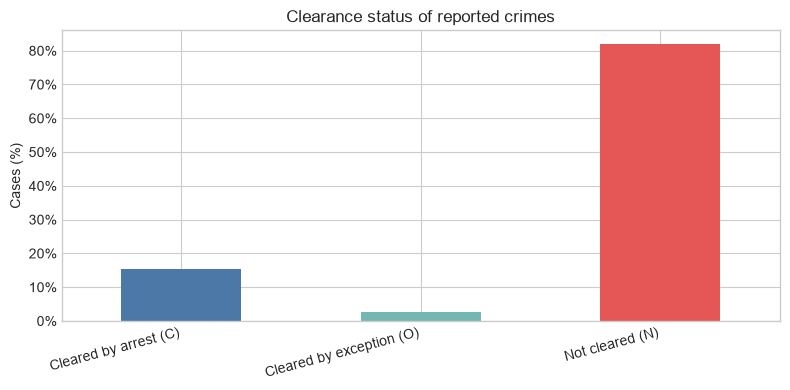

In [4]:
status_summary = cases['clearance_status'].value_counts().reindex(['C', 'O', 'N'])
status_summary = status_summary.to_frame('cases')
status_summary['percent'] = status_summary['cases'] / status_summary['cases'].sum() * 100
status_summary.index = ['Cleared by arrest (C)', 'Cleared by exception (O)', 'Not cleared (N)']
display(status_summary.round(1))

ax = status_summary['percent'].plot(kind='bar', color=['#4C78A8', '#72B7B2', '#E45756'], figsize=(8, 4))
ax.set(title='Clearance status of reported crimes', xlabel='', ylabel='Cases (%)')
ax.yaxis.set_major_formatter(PercentFormatter())
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()
print(f"We found that {status_summary.loc['Not cleared (N)', 'percent']:.1f}% of valid reported cases were not cleared.")

## 2. Where do clearance rates differ?

We compare clearance rates across crime types and police districts to see where the largest gaps appear.

,cases,clearance_rate
crime_type,,
Theft: Purse Snatching,7,0.00
Theft: Auto Parts,228,0.90
Theft: from Building,216,1.40
Theft: BOV,10282,2.60
Theft: Coin Op Machine,150,4.70
Burglary,4845,11.20
Theft: Pocket Picking,425,12.20
Theft: All Other Larceny,12919,12.30
Theft,26610,13.50


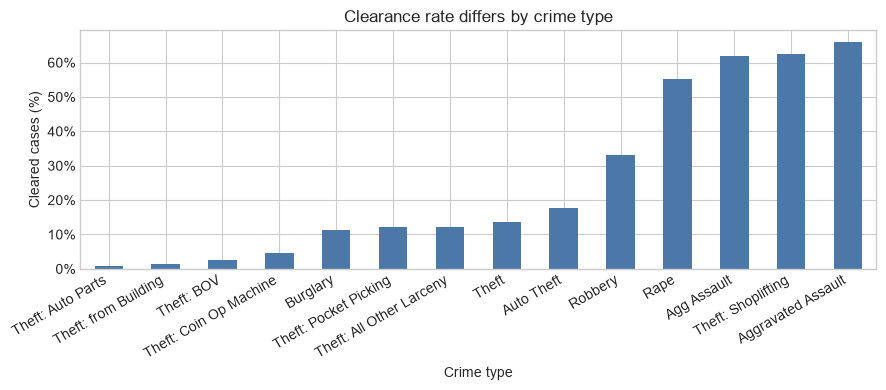

,cases,clearance_rate
district,,
B,8471,12.20
AP,275,13.80
G,5249,14.00
A,7853,15.30
C,5368,17.90
E,9303,18.60
F,8508,19.60
H,7009,20.20
D,10017,20.70


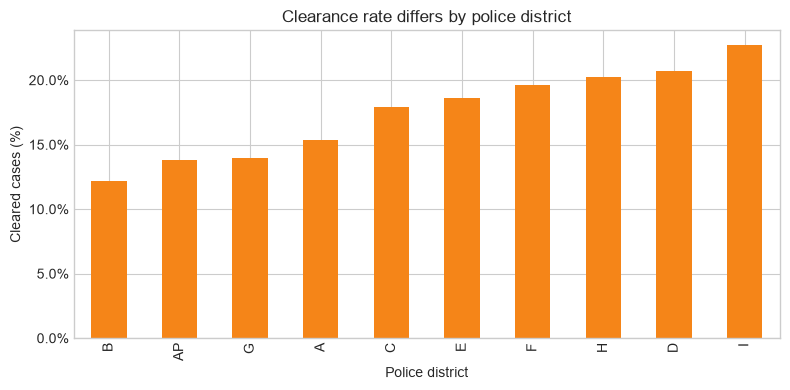

In [5]:
offense_summary = (
    cases.groupby('crime_type')
    .agg(cases=('case_id', 'size'), clearance_rate=('cleared', 'mean'))
    .sort_values('clearance_rate')
)
offense_summary['clearance_rate'] *= 100
display(offense_summary.round(1))

offense_plot = offense_summary.query('cases >= 100')
ax = offense_plot['clearance_rate'].plot(kind='bar', color='#4C78A8', figsize=(9, 4))
ax.set(title='Clearance rate differs by crime type', xlabel='Crime type', ylabel='Cleared cases (%)')
ax.yaxis.set_major_formatter(PercentFormatter())
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
lowest_type = offense_plot['clearance_rate'].idxmin()
highest_type = offense_plot['clearance_rate'].idxmax()
print(f"For crime types with at least 100 cases, clearance was lowest for {lowest_type} and highest for {highest_type}.")

district_summary = (
    cases.groupby('district')
    .agg(cases=('case_id', 'size'), clearance_rate=('cleared', 'mean'))
    .query('cases >= 50')
    .sort_values('clearance_rate')
)
district_summary['clearance_rate'] *= 100
display(district_summary.round(1))

ax = district_summary['clearance_rate'].plot(kind='bar', color='#F58518', figsize=(8, 4))
ax.set(title='Clearance rate differs by police district', xlabel='Police district', ylabel='Cleared cases (%)')
ax.yaxis.set_major_formatter(PercentFormatter())
plt.tight_layout()
plt.show()
print(f"Across districts, the clearance rate ranged from {district_summary['clearance_rate'].min():.1f}% to {district_summary['clearance_rate'].max():.1f}%.")

## 3. Which cleared case types take the longest?

We calculate the average and standard deviation of days from the report date to the recorded clearance date for C/O cases only.

,count,mean,std
crime_type,,,
Agg Assault,1131,13.10,19.30
Theft: Shoplifting,2435,14.70,30.30
Theft: Coin Op Machine,7,15.60,26.40
Theft,3594,15.60,29.90
Aggravated Assault,1203,16.20,23.80
Theft: Pocket Picking,52,18.10,22.50
Theft: BOV,271,20.30,39.50
Theft: from Building,3,21.70,13.40
Homicide: Murder & Nonnegligent Manslaughter,21,24.80,40.50


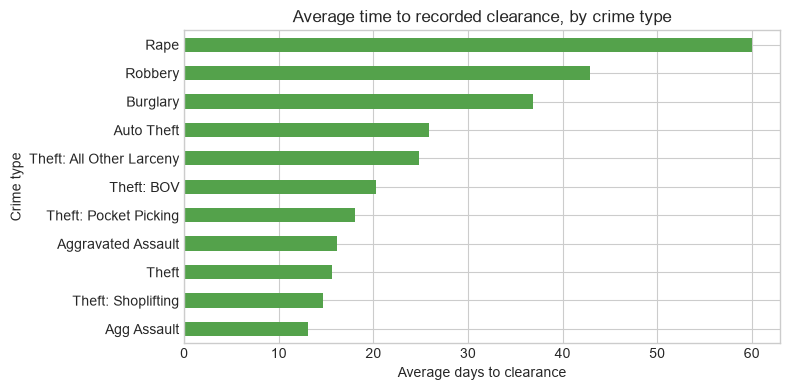

In [6]:
delay_by_type = (
    cleared_cases.groupby('crime_type')['days_to_clearance']
    .agg(['count', 'mean', 'std'])
    .sort_values('mean')
)
display(delay_by_type.round(1))
slowest_type = delay_by_type['mean'].idxmax()
slowest_days = delay_by_type.loc[slowest_type, 'mean']

delay_plot = delay_by_type.query('count >= 50')
ax = delay_plot['mean'].plot(kind='barh', color='#54A24B', figsize=(8, 4))
ax.set(title='Average time to recorded clearance, by crime type', xlabel='Average days to clearance', ylabel='Crime type')
plt.tight_layout()
plt.show()
print(f"Among the cleared case types, {slowest_type} took the longest on average: {slowest_days:.1f} days.")

## 4. Do arrest and exception clearances take different amounts of time?

We use a Welch t-test to compare the average clearance time for C and O cases. This version is appropriate because the two groups have different sizes and may have different variability.

,n,mean days,SD days
Cleared by arrest (C),10766,18.71,35.45
Cleared by exception (O),1907,34.56,41.49


Welch t-test: t = -15.698, p = 5.76e-53


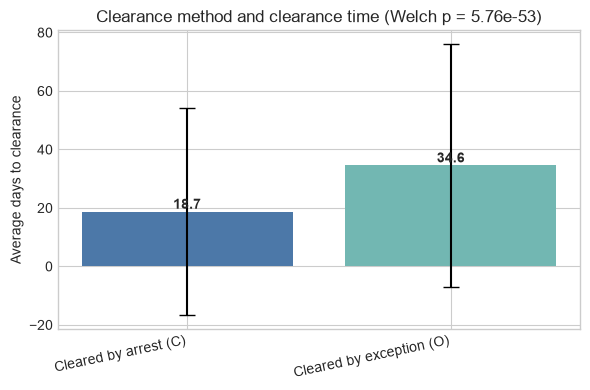

In [7]:
arrest_days = cleared_cases.loc[cleared_cases['clearance_status'] == 'C', 'days_to_clearance']
exception_days = cleared_cases.loc[cleared_cases['clearance_status'] == 'O', 'days_to_clearance']
t_stat, p_value = stats.ttest_ind(arrest_days, exception_days, equal_var=False)

test_table = pd.DataFrame({
    'n': [len(arrest_days), len(exception_days)],
    'mean days': [arrest_days.mean(), exception_days.mean()],
    'SD days': [arrest_days.std(), exception_days.std()]
}, index=['Cleared by arrest (C)', 'Cleared by exception (O)'])
display(test_table.round(2))

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(test_table.index, test_table['mean days'], yerr=test_table['SD days'], capsize=6, color=['#4C78A8', '#72B7B2'])
for bar, value in zip(bars, test_table['mean days']):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 1, f'{value:.1f}', ha='center', fontweight='bold')
ax.set(title=f'Clearance method and clearance time (Welch p = {p_value:.4g})', ylabel='Average days to clearance')
plt.xticks(rotation=12, ha='right')
plt.tight_layout()
plt.show()
print(f"Welch t-test: t = {t_stat:.3f}, p = {p_value:.4g}.")
if p_value < 0.05:
    print(f"Exception clearances took {exception_days.mean() - arrest_days.mean():.1f} more days on average than arrest clearances.")
    print('The very small p-value means this difference is very unlikely to be due to random sampling variation. It does not tell us why an exception clearance took longer.')
else:
    print('We did not find a statistically significant difference in average clearance time.')

### 4.1 Looking within the same crime type

We then compare separate C and O cases within the same crime type. One case has only one clearance status, but a crime type can include cases cleared both ways. We keep types with at least 30 cases in each group so the comparisons are more stable.

,arrest_cases,arrest_mean_days,exception_cases,exception_mean_days
crime_type,,,,
Agg Assault,885,11.65,246,18.18
Aggravated Assault,919,14.77,284,20.77
Auto Theft,572,22.86,157,37.00
Burglary,427,32.43,116,53.14
Rape,231,66.13,297,55.20
Robbery,461,40.46,89,55.38
Theft,3280,13.77,314,34.92
Theft: All Other Larceny,1272,23.83,315,28.66
Theft: BOV,241,20.54,30,18.27


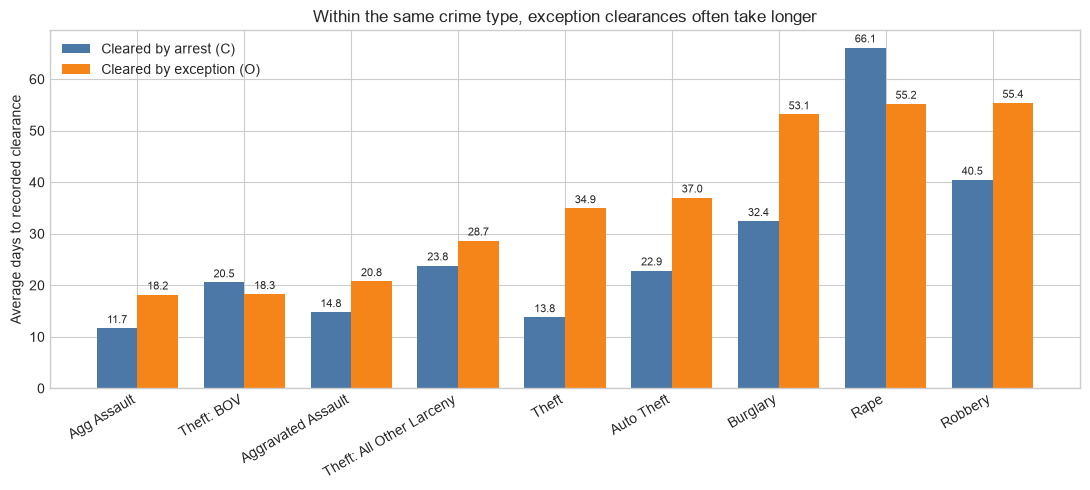

In [8]:
arrest_by_type = (
    cleared_cases[cleared_cases['clearance_status'] == 'C']
    .groupby('crime_type')['days_to_clearance']
    .agg(arrest_cases='count', arrest_mean_days='mean')
)
exception_by_type = (
    cleared_cases[cleared_cases['clearance_status'] == 'O']
    .groupby('crime_type')['days_to_clearance']
    .agg(exception_cases='count', exception_mean_days='mean')
)
method_by_type = arrest_by_type.join(exception_by_type).query('arrest_cases >= 30 and exception_cases >= 30')
display(method_by_type.round(2))

plot_methods = method_by_type.sort_values('exception_mean_days')
x = np.arange(len(plot_methods))
width = 0.38
fig, ax = plt.subplots(figsize=(11, 5))
bars_c = ax.bar(x - width / 2, plot_methods['arrest_mean_days'], width, label='Cleared by arrest (C)', color='#4C78A8')
bars_o = ax.bar(x + width / 2, plot_methods['exception_mean_days'], width, label='Cleared by exception (O)', color='#F58518')
ax.bar_label(bars_c, fmt='%.1f', padding=2, fontsize=8)
ax.bar_label(bars_o, fmt='%.1f', padding=2, fontsize=8)
ax.set_xticks(x, plot_methods.index, rotation=30, ha='right')
ax.set(title='Within the same crime type, exception clearances often take longer', ylabel='Average days to recorded clearance')
ax.legend()
plt.tight_layout()
plt.show()
exception_slower = (method_by_type['exception_mean_days'] > method_by_type['arrest_mean_days']).sum()
slowest_exception_type = method_by_type['exception_mean_days'].idxmax()
print(f"Exception clearance took longer in {exception_slower} of {len(method_by_type)} crime types shown here.")
print(f"The longest average exception-clearance time was for {slowest_exception_type}: {method_by_type.loc[slowest_exception_type, 'exception_mean_days']:.1f} days.")

In [15]:
# We already loaded and cleaned the data above.
# The next section reuses the same valid cases.

,address,census_tract,clearance_date,clearance_status,council_district_code,description,district,latitude,location,location_description,longitude,primary_type,timestamp,unique_key,x_coordinate,y_coordinate,year,zipcode
0,2620 RIO GRANDE ST Austin TX 78705,6.03,2015-12-14 00:00:00,Not cleared,9.00,THEFT,B,NaN,NaN,2620 RIO GRANDE ST,NaN,Theft,2015-12-13 00:00:00,"20,155,054,365.00","3,113,531.00","10,079,579.00","2,015.00","78,705.00"
1,9500 S IH 35 SVRD SB Austin TX 78748,24.21,2015-09-14 00:00:00,Cleared by Arrest,5.00,THEFT BY SHOPLIFTING,F,NaN,NaN,9500 S IH 35 SVRD SB,NaN,Theft,2015-09-03 00:00:00,"20,152,461,290.00","3,099,459.00","10,032,098.00","2,015.00","78,748.00"
2,1000 E 41ST ST,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Austin TX 78751,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,(30.298356 -97.719647),3.02,2014-07-29 00:00:00,Cleared by Arrest,9.00,THEFT BY SHOPLIFTING,B,30.30,(30.298356-97.719647),1000 E 41ST ST,-97.72,Theft: Shoplifting,2014-04-04 00:00:00,"2,014,941,460.00","3,121,345.00","10,082,705.00","2,014.00","78,751.00"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159459,(30.207396 -97.728709),24.31,2014-06-04 00:00:00,Not cleared,2.00,THEFT OF METAL,F,30.21,(30.207396-97.728709),4000 CAVEN RD,-97.73,Theft: All Other Larceny,2014-06-03 00:00:00,"20,145,024,656.00","3,119,195.00","10,048,844.00","2,014.00","78,744.00"
159460,10713 JOLLYVILLE RD Austin TX 78759,17.22,2016-01-12 00:00:00,Not cleared,10.00,THEFT BY SHOPLIFTING,A,NaN,NaN,10713 JOLLYVILLE RD,NaN,Theft,2015-12-30 00:00:00,"20,155,056,906.00","3,111,397.00","10,118,845.00","2,015.00","78,759.00"
159461,1712 TIMBER RIDGE DR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
159462,Austin TX 78741,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Does local crime volume relate to clearance rate?

We group cases by zip code, count reported crimes, and compare that count with each zip code's clearance rate.

We check whether areas with more reported crime tend to have higher or lower clearance rates.

Pearson correlation (r): 0.301
p-value: 0.06609


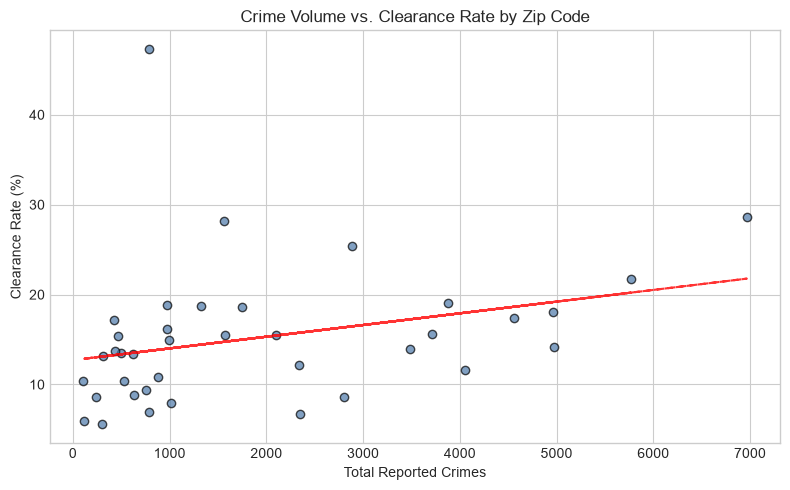

In [16]:
# We reuse the cleaned C/O/N cases so this section follows the same status rules as the rest of the notebook.
zip_stats = cases.groupby('zip_code').agg(
    total_crimes=('case_id', 'count'),
    clearance_rate=('cleared', 'mean')
).dropna()

# We keep zip codes with at least 100 cases so very small areas do not dominate the pattern.
zip_stats = zip_stats[zip_stats['total_crimes'] >= 100]
zip_stats['clearance_rate'] *= 100  # Convert to percentage

# We plot the relationship and add a fitted line to make the overall direction easier to see.
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(zip_stats['total_crimes'], zip_stats['clearance_rate'], color='#4C78A8', alpha=0.7, edgecolors='k')

# Fitted trend line
z = np.polyfit(zip_stats['total_crimes'], zip_stats['clearance_rate'], 1)
p = np.poly1d(z)
ax.plot(zip_stats['total_crimes'], p(zip_stats['total_crimes']), "r--", alpha=0.8)

ax.set(title='Crime Volume vs. Clearance Rate by Zip Code', 
       xlabel='Total Reported Crimes', 
       ylabel='Clearance Rate (%)')

# We calculate Pearson's r and its p-value.
r, p_value = stats.pearsonr(zip_stats['total_crimes'], zip_stats['clearance_rate'])

plt.tight_layout()
plt.show()
print(f"Pearson correlation: r = {r:.3f}, p = {p_value:.4g}.")
if p_value < 0.05:
    print('The sign of r shows the direction of the relationship, and the p-value gives evidence that the pattern is unlikely to be random.')
else:
    print('The positive r suggests a small upward pattern, but the p-value is above 0.05. We cannot claim a reliable relationship between zip-code crime volume and clearance rate.')